# ST2195 Coursework – Part 1: Random Walk Metropolis

**Target distribution:** $f(x) = \frac{1}{2}\,e^{-|x|}$ — the standard **Laplace (double-exponential)** distribution  
with mean **0** and standard deviation **$\sqrt{2} \approx 1.4142$**.

The notebook is structured as:
- **Section 1 — Setup:** shared sampler and target density
- **Section 2 — Part 1(a):** density estimation with histogram, KDE and true density overlay
- **Section 3 — Part 1(b):** Gelman-Rubin $\hat{R}$ convergence diagnostic

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

## 1  Setup — Target Density and Sampler

In [2]:
# Target density  f(x) = 0.5 * exp(-|x|)
def f(x):
    return 0.5 * np.exp(-np.abs(x))

def log_f(x):
    """log f(x) = log(0.5) - |x|
    Using the log form avoids numerical underflow in the acceptance ratio."""
    return np.log(0.5) - np.abs(x)


def rwm(N, s, x0=0.0, seed=42):
    """
    Random Walk Metropolis algorithm.

    Parameters
    ----------
    N    : number of MCMC iterations
    s    : proposal standard deviation  (Normal proposal centred at current state)
    x0   : initial value
    seed : random seed for reproducibility

    Returns
    -------
    chain : numpy array of length N+1  containing [x0, x1, ..., xN]

    Algorithm
    ---------
    At step i:
      1. Propose  x* ~ Normal(x_{i-1}, s)
      2. Compute  log r = log f(x*) - log f(x_{i-1})
      3. Draw     log u = log(Uniform(0,1))
      4. Accept x* if log u < log r, otherwise stay at x_{i-1}
    """
    rng   = np.random.default_rng(seed)
    chain = np.empty(N + 1)
    chain[0] = x0
    for i in range(1, N + 1):
        x_star = rng.normal(chain[i - 1], s)
        log_r  = log_f(x_star) - log_f(chain[i - 1])   # log acceptance ratio
        log_u  = np.log(rng.uniform())                  # log U(0,1)
        chain[i] = x_star if log_u < log_r else chain[i - 1]
    return chain

## 2  Part 1(a) — Sampling and Density Estimation (N = 10,000, s = 1)

In [3]:
N_a, s_a = 10_000, 1.0
full_chain_a = rwm(N_a, s_a, x0=0.0, seed=42)
samples      = full_chain_a[1:]          # x1 … xN  (discard x0)

# ── Monte Carlo estimates ────────────────────────────────────────────────────
mc_mean = samples.mean()
mc_std  = samples.std(ddof=1)

print("Monte Carlo Estimates of the Laplace distribution:")
print(f"  Mean  : {mc_mean:+.4f}   (true value = 0.0000)")
print(f"  Std   :  {mc_std:.4f}   (true value = {np.sqrt(2):.4f}  [= sqrt(2)])")

Monte Carlo Estimates of the Laplace distribution:
  Mean  : +0.0195   (true value = 0.0000)
  Std   :  1.4928   (true value = 1.4142  [= sqrt(2)])


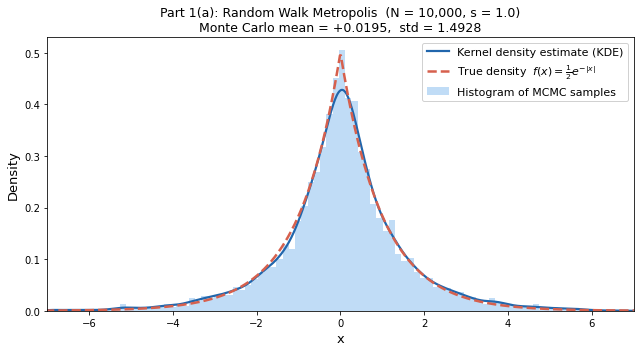

In [4]:
# ── Figure: Histogram + KDE + True density ──────────────────────────────────
x_grid = np.linspace(-8, 8, 800)
kde    = gaussian_kde(samples, bw_method="scott")

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(samples, bins=100, density=True,
        color="#4C9BE8", alpha=0.35, edgecolor="none",
        label="Histogram of MCMC samples")

ax.plot(x_grid, kde(x_grid),
        color="#2166AC", lw=2.2,
        label="Kernel density estimate (KDE)")

ax.plot(x_grid, f(x_grid),
        color="#D6604D", lw=2.5, ls="--",
        label=r"True density  $f(x)=\frac{1}{2}e^{-|x|}$")

ax.set_xlim(-7, 7)
ax.set_xlabel("x", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title(
    f"Part 1(a): Random Walk Metropolis  (N = {N_a:,}, s = {s_a})\n"
    f"Monte Carlo mean = {mc_mean:+.4f},  std = {mc_std:.4f}",
    fontsize=12.5
)
ax.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.savefig("part1a_plot.png", dpi=150)
plt.show()

**Interpretation:** The KDE (solid blue) and histogram (shaded) both closely follow the true 
Laplace density (dashed red), confirming the algorithm has converged.  
The Monte Carlo estimates of the mean ($\approx 0$) and std ($\approx \sqrt{2}$) match the true values well.

## 3  Part 1(b) — Gelman-Rubin $\hat{R}$ Convergence Diagnostic

The Gelman-Rubin statistic compares *within-chain* and *between-chain* variance across $J$ parallel 
chains started from **dispersed** initial values. If all chains have converged to the same 
stationary distribution, $B \approx 0$ and $\hat{R} \approx 1$.

$$M_j = \frac{1}{N}\sum_{i=1}^N x_i^{(j)}, \qquad V_j = \frac{1}{N}\sum_{i=1}^N (x_i^{(j)} - M_j)^2$$

$$W = \frac{1}{J}\sum_{j=1}^J V_j \quad(\text{within}), \qquad M = \frac{1}{J}\sum_{j=1}^J M_j, \qquad B = \frac{1}{J}\sum_{j=1}^J (M_j - M)^2 \quad(\text{between})$$

$$\boxed{\hat{R} = \sqrt{\frac{B + W}{W}}}$$

$\hat{R} < 1.05$ is the standard convergence criterion.

In [5]:
def gelman_rubin(N, s, J=4, x0_list=(-3.0, -1.0, 1.0, 3.0), seed=10):
    """
    Compute the Gelman-Rubin R-hat for J independent chains.

    Chains are initialised at dispersed values (x0_list) so that
    convergence genuinely needs to be achieved rather than assumed.
    """
    x0_list = list(x0_list)
    chains  = [rwm(N, s, x0=x0_list[j], seed=seed + j)[1:]   # drop x0
               for j in range(J)]

    M_j = np.array([c.mean()                     for c in chains])
    V_j = np.array([np.mean((c - c.mean()) ** 2) for c in chains])

    W = V_j.mean()                        # within-chain variance
    M = M_j.mean()                        # grand mean
    B = np.mean((M_j - M) ** 2)           # between-chain variance

    return np.sqrt((B + W) / W)

# ── Single required value: s = 0.001, N = 2000, J = 4 ──────────────────────
N_b = 2000;  J = 4
x0_dispersed = [-3.0, -1.0, 1.0, 3.0]

rhat_s001 = gelman_rubin(N_b, 0.001, J=J, x0_list=x0_dispersed, seed=10)
print(f"R-hat at s=0.001, N={N_b}, J={J} : {rhat_s001:.4f}")
print()
print("This is far above 1.05.")
print("Reason: with s=0.001 the chain almost never accepts a proposal.")
print("Each chain stays near its starting value, so between-chain variance >> within-chain variance.")

R-hat at s=0.001, N=2000, J=4 : 151.0186

This is far above 1.05.
Reason: with s=0.001 the chain almost never accepts a proposal.
Each chain stays near its starting value, so between-chain variance >> within-chain variance.


R-hat first drops below 1.05 at s ≈ 0.191  (R-hat = 1.0385)


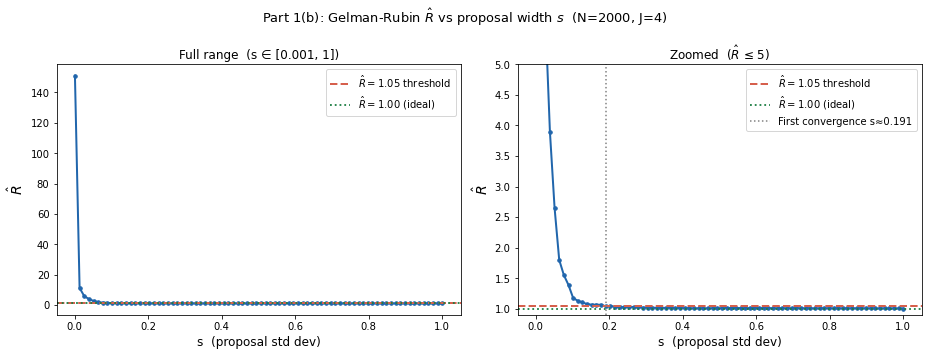

In [6]:
# ── R-hat over a grid of s ──────────────────────────────────────────────────
s_grid = np.linspace(0.001, 1.0, 80)
rhats  = [gelman_rubin(N_b, s, J=J, x0_list=x0_dispersed, seed=10)
          for s in s_grid]

# Locate first s where R-hat < 1.05
below = next(((s, r) for s, r in zip(s_grid, rhats) if r < 1.05), None)
if below:
    print(f"R-hat first drops below 1.05 at s ≈ {below[0]:.3f}  (R-hat = {below[1]:.4f})")

# ── Two-panel figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (title, ylim) in zip(
        axes,
        [("Full range  (s ∈ [0.001, 1])", None),
         (r"Zoomed  ($\hat{R}$ ≤ 5)",     (0.9, 5))]):

    ax.plot(s_grid, rhats, color="#2166AC", lw=2, marker="o", ms=3.5)
    ax.axhline(1.05, color="#D6604D", ls="--", lw=2,
               label=r"$\hat{R}=1.05$ threshold")
    ax.axhline(1.00, color="#1A7D41", ls=":",  lw=1.8,
               label=r"$\hat{R}=1.00$ (ideal)")
    if below and ylim:
        ax.axvline(below[0], color="grey", ls=":", lw=1.5,
                   label=f"First convergence s≈{below[0]:.3f}")
    if ylim:
        ax.set_ylim(ylim)
    ax.set_xlabel("s  (proposal std dev)", fontsize=12)
    ax.set_ylabel(r"$\hat{R}$", fontsize=14)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)

fig.suptitle(
    fr"Part 1(b): Gelman-Rubin $\hat{{R}}$ vs proposal width $s$  (N={N_b}, J={J})",
    fontsize=13
)
plt.tight_layout()
plt.savefig("part1b_plot.png", dpi=150)
plt.show()

**Interpretation:**

- At **s = 0.001** the acceptance rate is near zero; chains remain frozen near their start points.  
  Between-chain variance $B$ dominates, giving $\hat{R} \approx 151$ — far from convergence.
- As $s$ increases, chains mix more and $\hat{R}$ drops sharply.
- $\hat{R}$ **first falls below 1.05 at s ≈ 0.191**, indicating adequate mixing.
- For $s \gtrsim 0.2$ through $s = 1$, the algorithm converges reliably with $\hat{R} \approx 1$.